# BERT 编码器

> Transformer 论文提出的原始架构同时包含 Encoder 和 Decoder——Encoder 负责读取并理解输入，Decoder 负责逐个 token 生成输出。前几节我们只取了 Decoder 侧，实现了 GPT 这样的 Decoder-Only 模型。
>
> 这一节从原始 Transformer 的完整实现开始，然后转向 Encoder 侧，从零实现 Encoder-Only 模型 MiniBERT。去掉 causal mask 后，token 的视野从单向变成双向，训练目标也从「预测下一个词」变成「遮住一些词，根据上下文猜它们是什么」——MLM（Masked Language Modeling）。

MLM 的直观理解并不复杂：一句话里遮掉一个词，让人猜被遮住的是什么。比如「我 ＿＿ 你」——只给三个字，中文母语者大概也能猜到空白处填什么。BERT 学做的就是这件事。

GPT 的训练围绕生成：逐个 token 往后写，写的时候不知道后面是什么。BERT 反过来——不生成，先读完整句话，再回答关于这句话的问题。感情色彩是正面还是负面、文中有哪些地名、两句话是否矛盾——对这些任务，先读完再判断比逐词猜更直接。

## 1. 原始 Transformer：Encoder + Decoder

2017 年的 Transformer 论文（"Attention Is All You Need"）提出的是完整的 Encoder-Decoder 架构，用于机器翻译：Encoder 读取源语言句子，Decoder 逐个 token 生成目标语言句子。[The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) 是一份逐行注释的经典实现。

这个架构包含三种 Attention：

- **Encoder 自注意力**：双向的，每个 token 能看到输入序列的所有位置
- **Decoder 自注意力**：单向的（causal mask），生成时只能看到已经生成的部分
- **Cross-attention**：Decoder 的每个位置查询 Encoder 的输出，获取源语言信息

下面从零实现这个完整架构，并在一个复制任务上训练——让模型学会把输入序列原样输出。复制任务虽然简单，但它完整展示了 Encoder-Decoder 的工作流程：Encoder 编码输入，Decoder 逐步解码输出。

In [1]:
# ============================================================
# 原始 Transformer：Encoder + Decoder 完整实现
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")


# 多头注意力，支持 mask（因果 mask / padding mask）
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        Q = self.W_Q(query).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(key).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(value).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(
            B, -1, self.num_heads * self.d_k
        )
        return self.W_O(out)


# 正弦余弦位置编码（原始 Transformer 的方式）
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# Encoder 层：双向自注意力 + FFN
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        normed = self.norm1(x)
        x = x + self.attn(normed, normed, normed, mask)
        x = x + self.ffn(self.norm2(x))
        return x


# Decoder 层：因果自注意力 + cross-attention + FFN
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, memory, src_mask=None, tgt_mask=None):
        # 因果自注意力：只能看到已经生成的 token
        normed = self.norm1(x)
        x = x + self.self_attn(normed, normed, normed, tgt_mask)
        # Cross-attention：查询 Encoder 的输出
        normed = self.norm2(x)
        x = x + self.cross_attn(normed, memory, memory, src_mask)
        # FFN
        x = x + self.ffn(self.norm3(x))
        return x


# 完整的 Encoder-Decoder Transformer
class EncoderDecoderTransformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=64, num_heads=4,
                 d_ff=256, num_layers=2, max_len=50):
        super().__init__()
        self.d_model = d_model
        self.src_embed = nn.Sequential(
            nn.Embedding(src_vocab, d_model),
            PositionalEncoding(d_model, max_len),
        )
        self.tgt_embed = nn.Sequential(
            nn.Embedding(tgt_vocab, d_model),
            PositionalEncoding(d_model, max_len),
        )
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.generator = nn.Linear(d_model, tgt_vocab)

    def encode(self, src, src_mask=None):
        x = self.src_embed(src)
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return self.norm(x)

    def decode(self, tgt, memory, src_mask=None, tgt_mask=None):
        x = self.tgt_embed(tgt)
        for layer in self.decoder_layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        memory = self.encode(src, src_mask)
        out = self.decode(tgt, memory, src_mask, tgt_mask)
        return self.generator(out)


# 创建模型
VOCAB_SIZE = 11  # token 0-10，其中 0 是起始符
transformer = EncoderDecoderTransformer(VOCAB_SIZE, VOCAB_SIZE).to(device)
total_params = sum(p.numel() for p in transformer.parameters())
print(f"模型参数量: {total_params:,}")
print(f"架构: {len(transformer.encoder_layers)} 层 Encoder"
      f" + {len(transformer.decoder_layers)} 层 Decoder")
print("注意力类型: Encoder 自注意力（双向）"
      " + Decoder 自注意力（因果） + Cross-attention")

使用设备: cuda
模型参数量: 234,187
架构: 2 层 Encoder + 2 层 Decoder
注意力类型: Encoder 自注意力（双向） + Decoder 自注意力（因果） + Cross-attention


=== 训练 Encoder-Decoder Transformer（复制任务）===


  Epoch   0 | Loss: 2.4860


  Epoch  50 | Loss: 0.9780


  Epoch 100 | Loss: 0.0262


  Epoch 150 | Loss: 0.0129


  Epoch 200 | Loss: 0.0056


  Epoch 250 | Loss: 0.0038


  Epoch 299 | Loss: 0.0028

初始 Loss: 2.4860 -> 最终 Loss: 0.0028

=== 测试（自回归解码）===
  输入:   [10, 4, 3, 9, 8, 1, 9, 5]
  输出:   [10, 4, 3, 9, 8, 1, 9, 5]
  复制正确: True


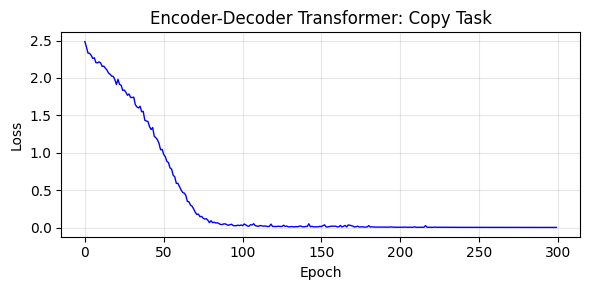

In [2]:
# ============================================================
# 复制任务：训练 Transformer 学会原样输出输入序列
# ============================================================

import torch
import torch.nn.functional as F

torch.manual_seed(42)

SEQ_LEN = 8
BATCH_SIZE = 32
NUM_EPOCHS = 300

optimizer = torch.optim.Adam(transformer.parameters(), lr=0.001)


def make_causal_mask(seq_len):
    # 因果 mask：下三角矩阵，防止 Decoder 看到未来的 token
    return torch.tril(torch.ones(seq_len, seq_len, device=device)).unsqueeze(0).unsqueeze(0)


def make_batch():
    # 生成训练数据：随机序列 -> 原样复制
    src = torch.randint(1, 11, (BATCH_SIZE, SEQ_LEN), device=device)  # token 1-10
    # Decoder 输入：起始符 0 + src 的前 seq_len-1 个
    tgt_input = torch.cat([
        torch.zeros(BATCH_SIZE, 1, dtype=torch.long, device=device),
        src[:, :-1]
    ], dim=1)
    tgt_output = src  # 目标就是原序列
    return src, tgt_input, tgt_output


tgt_mask = make_causal_mask(SEQ_LEN)

# 训练
print("=== 训练 Encoder-Decoder Transformer（复制任务）===")
transformer.train()
losses = []
for epoch in range(NUM_EPOCHS):
    src, tgt_in, tgt_out = make_batch()
    logits = transformer(src, tgt_in, tgt_mask=tgt_mask)
    loss = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1)
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 50 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"\n初始 Loss: {losses[0]:.4f} -> 最终 Loss: {losses[-1]:.4f}")

# ============================================================
# 测试：自回归解码（逐步生成，和真实翻译的推理过程相同）
# ============================================================
transformer.eval()
with torch.no_grad():
    test_src = torch.randint(1, 11, (1, SEQ_LEN), device=device)
    # 从起始符开始，逐个生成
    generated = torch.zeros(1, 1, dtype=torch.long, device=device)
    for step in range(SEQ_LEN):
        mask = make_causal_mask(step + 1)
        logits = transformer(test_src, generated, tgt_mask=mask)
        next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_tok], dim=1)

    result = generated[:, 1:]  # 去掉起始符
    print(f"\n=== 测试（自回归解码）===")
    print(f"  输入:   {test_src.cpu().tolist()[0]}")
    print(f"  输出:   {result.cpu().tolist()[0]}")
    print(f"  复制正确: {(result == test_src).all().item()}")

# Loss 曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Encoder-Decoder Transformer: Copy Task')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Encoder 与 Decoder

上面的完整 Transformer 同时使用了 Encoder 和 Decoder。实际应用中，只用其中一侧也能取得很好的效果：GPT 只用 Decoder，BERT 只用 Encoder。两者的根本差异在于 Attention 的方向——给定句子「我把苹果吃了」，causal mask 下模型看到「我把」时完全不知道后面是「苹果」还是「手机」——只能猜。双向 Attention 下，模型同时看到「我」「把」「苹果」「吃了」——每个词都能参考整句话的所有位置，所以它知道「苹果」是宾语而不是主语。

这个区别决定了模型适合做什么。GPT 适合生成——每次只能看到已经写出来的部分，写完一个词才能看下一个。BERT 适合理解——先通读全文，再回答关于这篇文章的任何问题。

用「我把苹果吃了」来看每个 token 的视野范围：

```
BERT（双向，无 mask）              GPT（因果，有 mask）

  "我"   → 我, 把, 苹果, 吃了       "我"   → 我
  "把"   → 我, 把, 苹果, 吃了       "把"   → 我, 把
  "苹果" → 我, 把, 苹果, 吃了       "苹果" → 我, 把, 苹果
  "吃了" → 我, 把, 苹果, 吃了       "吃了" → 我, 把, 苹果, 吃了
```

BERT 没有对 Attention 做任何限制，矩阵中每个位置都是可见的。GPT 通过一个下三角矩阵做 mask，把"未来"的信息挡住。这个看似简单的区别，直接决定了两种架构的适用场景。

## 3. BERT 的输入表示

BERT 的输入不是简单的一个 Embedding，而是**三个 Embedding 相加**：

```
输入 = Token Embedding + Segment Embedding + Position Embedding
         ↑                    ↑                    ↑
   "这个词本身是谁"    "属于句子A还是句子B"   "在哪个位置"
```

这和 GPT 的区别在哪？GPT 只有 Token + Position，不需要 Segment（因为 GPT 不处理"两个句子之间的关系"）。

**为什么 BERT 需要 Segment Embedding？** 因为 NSP（下一句预测）任务需要判断两个句子的关系。

下面用代码展示 BERT 的「完整输入构造过程」：

In [3]:
# ============================================================
# 手动构造 BERT 的输入（从零开始，一步步展示）
# ============================================================

# 模拟一个小 BERT 的配置
import torch
import torch.nn as nn
torch.manual_seed(42)
VOCAB_SIZE = 100
D_MODEL = 16
MAX_LEN = 20
NUM_SEGMENTS = 2  # 句子 A 或 句子 B

# 三个 Embedding
token_embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
segment_embed = nn.Embedding(NUM_SEGMENTS, D_MODEL)
position_embed = nn.Embedding(MAX_LEN, D_MODEL)

# 模拟输入：两个句子
#   [CLS] 我 喜欢 猫 [SEP] 他 喜欢 狗 [SEP]
#   其中 [CLS]=1, [SEP]=2

sentence_A = [1, 5, 8, 3, 2]    # [CLS] 我 喜欢 猫 [SEP]
sentence_B = [6, 8, 4, 2]        # 他 喜欢 狗 [SEP]
full_ids = sentence_A + sentence_B
seq_len = len(full_ids)

print("Step 1: Token IDs")
print(f"  Input: {full_ids}")
print(f"  含义: [CLS] 我 喜欢 猫 [SEP] 他 喜欢 狗 [SEP]")

# Segment IDs：句子 A 的 token 标 0，句子 B 的 token 标 1
segment_ids = [0] * len(sentence_A) + [1] * len(sentence_B)
print(f"\nStep 2: Segment IDs")
print(f"  Segments: {segment_ids}")
print(f"  含义: 前 {len(sentence_A)} 个属于句子A(0)，后 {len(sentence_B)} 个属于句子B(1)")

# Position IDs：0, 1, 2, ..., seq_len-1
position_ids = list(range(seq_len))
print(f"\nStep 3: Position IDs")
print(f"  Positions: {position_ids}")

# ============================================================
# 三个 Embedding 相加
# ============================================================
tokens_t = torch.tensor(full_ids)
segments_t = torch.tensor(segment_ids)
positions_t = torch.tensor(position_ids)

tok_emb = token_embed(tokens_t)    # (seq_len, D_MODEL)
seg_emb = segment_embed(segments_t)  # (seq_len, D_MODEL)
pos_emb = position_embed(positions_t)  # (seq_len, D_MODEL)

input_embeddings = tok_emb + seg_emb + pos_emb

print(f"\nStep 4: 三个 Embedding 相加")
print(f"  Token Embedding shape:    {tok_emb.shape}")
print(f"  Segment Embedding shape:  {seg_emb.shape}")
print(f"  Position Embedding shape: {pos_emb.shape}")
print(f"  相加后: {input_embeddings.shape}")

# 展示：同一个词（"喜欢"，id=8）在两个句子中的 embedding 不同
# "喜欢" 在句子 A 的位置 2，在句子 B 的位置 1
idx_a = 2  # 句子 A 中的 "喜欢"
idx_b = len(sentence_A) + 1  # 句子 B 中的 "喜欢"

print(f"\n★ 关键证明：同一个词在不同位置 + 不同句子的 embedding 不同")
print(f"  '喜欢' 在句子A (pos={idx_a}, seg=0) 的最终 embedding (前 6 维):")
print(f"    {input_embeddings[idx_a, :6].detach()}")
print(f"  '喜欢' 在句子B (pos={idx_b}, seg=1) 的最终 embedding (前 6 维):")
print(f"    {input_embeddings[idx_b, :6].detach()}")
print(f"  它们一样吗？ {(input_embeddings[idx_a] == input_embeddings[idx_b]).all().item()}")
print(f"  → 即使词相同，但因为位置和 segment 不同，最终 embedding 也不同！")

Step 1: Token IDs
  Input: [1, 5, 8, 3, 2, 6, 8, 4, 2]
  含义: [CLS] 我 喜欢 猫 [SEP] 他 喜欢 狗 [SEP]

Step 2: Segment IDs
  Segments: [0, 0, 0, 0, 0, 1, 1, 1, 1]
  含义: 前 5 个属于句子A(0)，后 4 个属于句子B(1)

Step 3: Position IDs
  Positions: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Step 4: 三个 Embedding 相加
  Token Embedding shape:    torch.Size([9, 16])
  Segment Embedding shape:  torch.Size([9, 16])
  Position Embedding shape: torch.Size([9, 16])
  相加后: torch.Size([9, 16])

★ 关键证明：同一个词在不同位置 + 不同句子的 embedding 不同
  '喜欢' 在句子A (pos=2, seg=0) 的最终 embedding (前 6 维):
    tensor([ 1.7462,  1.3668, -1.6681, -0.8311, -0.6420,  3.6566])
  '喜欢' 在句子B (pos=6, seg=1) 的最终 embedding (前 6 维):
    tensor([ 1.8207, -0.1974, -1.4914,  0.9783, -1.8119,  1.2722])
  它们一样吗？ False
  → 即使词相同，但因为位置和 segment 不同，最终 embedding 也不同！


## 4. MLM 预训练

GPT 的训练任务是「给定前面的词，预测下一个词」（自回归）。
BERT 的训练任务是「遮住中间的某些词，让模型猜它们是什么」（MLM）。

```
GPT 的训练:  我 → 爱 → 你 → 中国
            只能看 → 方向

BERT 的训练: 我 [MASK] 你 中国  →  猜 [MASK] 是 "爱"
            看左边   看右边
```

BERT 能同时看到左右两边——因为它的 attention 是**双向**的（没有因果掩码）。
这使它擅长「理解」，但无法生成——因为它训练时从来没学过「一个一个往外蹦词」。

In [4]:
# ============================================================
# 演示 BERT 的双向 Attention（对比 GPT 的因果 Attention）
# ============================================================
import torch
seq_len = 6

# GPT 的因果掩码：每个位置只能看自己和前面的
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

# BERT 没有掩码：每个位置看所有位置（双向）
bert_mask = torch.ones(seq_len, seq_len)

tokens = ["[CLS]", "我", "爱", "你", "中", "[SEP]"]

print("=== GPT 的因果 Attention（单向）===")
print(f"Tokens: {tokens}")
print()
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if causal_mask[i, j] == 1]
    print(f"  位置 {i} ('{tokens[i]}') 能看到: {visible}")

print(f"\n=== BERT 的 Attention（双向）===")
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if bert_mask[i, j] == 1]
    print(f"  位置 {i} ('{tokens[i]}') 能看到: {visible}")

print(f"\n关键区别:")
print(f"  GPT:  '你' 看不到 '中国'（还没生成）")
print(f"  BERT: '你' 能看到 '中国'（整句已知，双向看）")
print(f"  → BERT 理解上下文的能力更强！但无法做生成。")


=== GPT 的因果 Attention（单向）===
Tokens: ['[CLS]', '我', '爱', '你', '中', '[SEP]']

  位置 0 ('[CLS]') 能看到: ['[CLS]']
  位置 1 ('我') 能看到: ['[CLS]', '我']
  位置 2 ('爱') 能看到: ['[CLS]', '我', '爱']
  位置 3 ('你') 能看到: ['[CLS]', '我', '爱', '你']
  位置 4 ('中') 能看到: ['[CLS]', '我', '爱', '你', '中']
  位置 5 ('[SEP]') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']

=== BERT 的 Attention（双向）===
  位置 0 ('[CLS]') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 1 ('我') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 2 ('爱') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 3 ('你') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 4 ('中') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 5 ('[SEP]') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']

关键区别:
  GPT:  '你' 看不到 '中国'（还没生成）
  BERT: '你' 能看到 '中国'（整句已知，双向看）
  → BERT 理解上下文的能力更强！但无法做生成。


## 5. MLM 训练演示

MLM 的训练思路很直接，但和自回归语言模型的训练有本质区别：

- **自回归模型**（如 GPT）：输入 token[0:n]，预测 token[1:n+1]，每个位置都参与 loss 计算。这是「从左到右逐个预测」的模式。
- **MLM**：只随机遮住 15% 的 token，模型看到完整上下文（包括被遮位置右边的内容），但要预测的只有被遮住的那 15%。Loss 只在被遮住的位置上计算。

为什么 MLM 只算 15% 位置的 loss？因为未被遮住的 token 模型可以直接「看到」自己，如果不加 mask 直接预测，模型只需要学会 copy 输入就行了，什么也学不到。

下面构建一个 MiniBERT，展示完整的 MLM 训练流程：
1. 随机遮住 15% 的 token（其中 80% 替换为 [MASK]，10% 替换为随机 token，10% 保持不变）
2. 模型利用双向上下文预测被遮住的 token
3. Loss 只在被遮住的位置上计算

In [5]:
# ============================================================
# MiniBERT：只用 Encoder（双向 Attention，无因果掩码）
# ============================================================
import torch.nn.functional as F
import math
import torch.nn as nn
import torch
class MiniBERTEncoder(nn.Module):
    """和 MiniGPT 类似的 Transformer Block，但没有因果掩码（双向）"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # ★ 没有 mask！双向！
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class MiniBERTBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attention = MiniBERTEncoder(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class MiniBERT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=64):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # BERT 使用学习式位置编码（不是正弦）
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            MiniBERTBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def encode(self, x):
        """返回每个位置的 hidden state，供分类/问答等任务复用"""
        B, S = x.shape
        positions = torch.arange(S, device=x.device).unsqueeze(0)
        x_emb = self.token_embedding(x) + self.position_embedding(positions)
        for block in self.blocks:
            x_emb = block(x_emb)
        x_emb = self.norm_final(x_emb)
        return x_emb

    def forward(self, x):
        x_emb = self.encode(x)
        return self.lm_head(x_emb)

print("MiniBERT 定义完毕（双向 Attention，无因果掩码）")


MiniBERT 定义完毕（双向 Attention，无因果掩码）


In [6]:
import torch.nn.functional as F
# ============================================================
# MLM 训练数据构造 + 训练演示
# ============================================================
import torch
VOCAB_SIZE = 50
MASK_ID = 3  # [MASK] 的 ID

torch.manual_seed(42)
model = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 模拟训练句子
sentences = [
    [5, 8, 10, 6, 9, 4],   # 我 喜欢 猫 它 很 可爱
    [5, 12, 13, 14, 4],    # 我 讨厌 下雨 天
    [7, 8, 11, 6, 15, 4],  # 他 喜欢 狗 它 忠诚
    [5, 16, 17, 18, 4],    # 我 在 学习 编程
    [7, 16, 19, 20, 4],    # 他 在 听 音乐
    [5, 21, 22, 9, 23, 4], # 我 觉得 数学 很 难
]

# MLM 数据构造函数
def create_mlm_batch(sentences, mask_prob=0.15):
    """
    和真实 BERT 一样：
    - 15% 的 token 被选中
    - 其中 80% 替换为 [MASK]
    - 10% 替换为随机 token
    - 10% 保持不变（但还是要预测）
    """
    # Padding
    max_len = max(len(s) for s in sentences)
    batch_size = len(sentences)
    input_ids = torch.zeros(batch_size, max_len, dtype=torch.long, device=device)
    labels = torch.full((batch_size, max_len), -100, dtype=torch.long, device=device)  # -100 = ignore

    for i, sent in enumerate(sentences):
        input_ids[i, :len(sent)] = torch.tensor(sent, device=device)

        # 选择要 mask 的位置（15%），但不 mask 第一个和最后一个
        maskable = list(range(1, len(sent) - 1))
        num_mask = max(1, int(len(maskable) * mask_prob))
        mask_positions = torch.randperm(len(maskable))[:num_mask]

        for pos_idx in mask_positions:
            pos = maskable[pos_idx]
            labels[i, pos] = sent[pos]  # 记录原始 token
            rand = torch.rand(1).item()
            if rand < 0.8:
                input_ids[i, pos] = MASK_ID  # 80%: 替换为 [MASK]
            elif rand < 0.9:
                input_ids[i, pos] = torch.randint(5, 25, (1,), device=device).item()  # 10%: 随机
            # 10%: 保持不变

    return input_ids, labels

# 创建 batch
input_ids, labels = create_mlm_batch(sentences)

print("=== MLM 训练数据示例 ===")
print(f"MASK_ID = {MASK_ID}")
print()
for i in range(len(sentences)):
    print(f"句子 {i+1}:")
    print(f"  原始: {sentences[i]}")
    print(f"  输入: {input_ids[i].cpu().tolist()}")
    label_row = labels[i].cpu().tolist()
    print(f"  labels: {[('MASK→'+str(l) if l != -100 else 'ignore') for l in label_row]}")
    print()

# ============================================================
# 训练
# ============================================================
print("=== 训练 MiniBERT (MLM) ===")
NUM_EPOCHS = 200
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    logits = model(input_ids)  # (B, S, V)
    loss = F.cross_entropy(
        logits.view(-1, VOCAB_SIZE),
        labels.view(-1),
        ignore_index=-100  # 忽略非 mask 位置
    )
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 20 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"\n初始 Loss: {losses[0]:.4f} → 最终 Loss: {losses[-1]:.4f}")


=== MLM 训练数据示例 ===
MASK_ID = 3

句子 1:
  原始: [5, 8, 10, 6, 9, 4]
  输入: [5, 8, 3, 6, 9, 4]
  labels: ['ignore', 'ignore', 'MASK→10', 'ignore', 'ignore', 'ignore']

句子 2:
  原始: [5, 12, 13, 14, 4]
  输入: [5, 3, 13, 14, 4, 0]
  labels: ['ignore', 'MASK→12', 'ignore', 'ignore', 'ignore', 'ignore']

句子 3:
  原始: [7, 8, 11, 6, 15, 4]
  输入: [7, 8, 11, 3, 15, 4]
  labels: ['ignore', 'ignore', 'ignore', 'MASK→6', 'ignore', 'ignore']

句子 4:
  原始: [5, 16, 17, 18, 4]
  输入: [5, 16, 17, 3, 4, 0]
  labels: ['ignore', 'ignore', 'ignore', 'MASK→18', 'ignore', 'ignore']

句子 5:
  原始: [7, 16, 19, 20, 4]
  输入: [7, 16, 19, 3, 4, 0]
  labels: ['ignore', 'ignore', 'ignore', 'MASK→20', 'ignore', 'ignore']

句子 6:
  原始: [5, 21, 22, 9, 23, 4]
  输入: [5, 21, 3, 9, 23, 4]
  labels: ['ignore', 'ignore', 'MASK→22', 'ignore', 'ignore', 'ignore']

=== 训练 MiniBERT (MLM) ===
Epoch   0 | Loss: 3.8524


Epoch  20 | Loss: 0.5691


Epoch  40 | Loss: 0.1018
Epoch  60 | Loss: 0.0474


Epoch  80 | Loss: 0.0309


Epoch 100 | Loss: 0.0227
Epoch 120 | Loss: 0.0177


Epoch 140 | Loss: 0.0142


Epoch 160 | Loss: 0.0116
Epoch 180 | Loss: 0.0097


Epoch 199 | Loss: 0.0083

初始 Loss: 3.8524 → 最终 Loss: 0.0083


=== MLM 预测结果 ===
输入:  [5, 3, 10, 6, 3, 4]
       ['我', '[MASK]', '猫', '它', '[MASK]', '可爱']
预测:  [12, 12, 10, 18, 12, 22]
       ['我', '?', '猫', '它', '?', '可爱']

位置 1 (预测) = 12 (期望 8='喜欢')
位置 4 (预测) = 12 (期望 9='很')


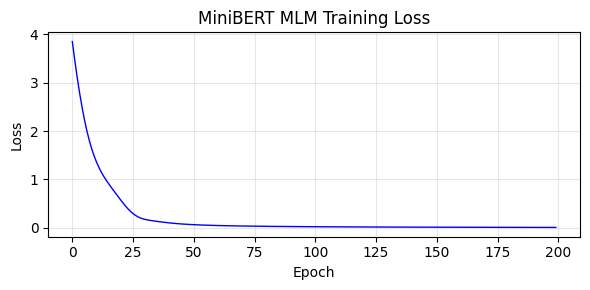

In [7]:
# ============================================================
# 测试：MLM 预测效果
# ============================================================
import torch
test_sentence = torch.tensor([[5, MASK_ID, 10, 6, MASK_ID, 4]], device=device)  # 我 [MASK] 猫 它 [MASK] 可爱

model.eval()
with torch.no_grad():
    logits = model(test_sentence)
    predictions = logits.argmax(dim=-1)

print("=== MLM 预测结果 ===")
print(f"输入:  {test_sentence.cpu().tolist()[0]}")
print(f"       ['我', '[MASK]', '猫', '它', '[MASK]', '可爱']")
print(f"预测:  {predictions.cpu().tolist()[0]}")
print(f"       ['我', '?', '猫', '它', '?', '可爱']")
print(f"\n位置 1 (预测) = {predictions[0, 1].item()} (期望 8='喜欢')")
print(f"位置 4 (预测) = {predictions[0, 4].item()} (期望 9='很')")

# Visualize loss
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MiniBERT MLM Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. BERT 的微调范式

BERT 预训练完后，不同下游任务只需在顶层接不同的分类头。关键问题是：**分类头接在哪里？**

预训练好的 BERT 本体是一个「通用文本编码器」——输入一段文本，输出每个 token 的 hidden state。不同任务需要的信息位置不同：

| 任务 | 需要什么信息 | 分类头接在哪里 |
|------|------------|-------------|
| **单句分类**（情感分析） | 整句话的语义 | `[CLS]` 的 hidden → 分类层 |
| **句对分类**（NLI、相似度） | 两句的关系 | `[CLS]` 的 hidden → 分类层 |
| **序列标注**（NER） | 每个词的类别 | **每个 token** 的 hidden → 各自的分类层 |
| **问答**（SQuAD） | 答案的起止位置 | 每个 token 的 hidden → start/end 两个分类层 |

为什么单句和句对分类都取 `[CLS]`？因为 `[CLS]` 在 BERT 的输入最前面，经过多层双向 Attention 后，整句话的信息被聚合到了 `[CLS]` 的 hidden state 里——它是一个「整句摘要」。直接拿它过一个分类层就能做句子级别的判断。

序列标注任务（比如 NER：给「苹果发布新手机」标注为 `[ORG, O, O, O]`）需要每个 token 各自的类别，所以不能只取 `[CLS]`——需要对每个位置的 hidden state 分别做分类。

核心洞察：经典 BERT fine-tuning 通常是在顶层加任务头，并让 BERT 本体和任务头一起微调；冻结 BERT 只训练头是一种省资源的选择，不是默认范式。这和 GPT 的 prompt engineering 不同：BERT 更常通过任务头和微调适配任务，GPT 更常通过 prompt / SFT / RL 等方式适配。


In [8]:
import torch.nn as nn
# ============================================================
# 演示：用 MiniBERT 做句子分类
# ============================================================
import torch
class MiniBERTForClassification(nn.Module):
    """在 MiniBERT 上接一个分类头"""
    def __init__(self, bert, num_classes):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.d_model, num_classes)

    def forward(self, x):
        hidden = self.bert.encode(x)  # (B, S, D)
        cls_output = hidden[:, 0, :]  # 取 [CLS] 的输出
        return self.classifier(cls_output)  # → (B, num_classes)

# 演示
VOCAB_SIZE = 50
bert_base = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2).to(device)
clf_model = MiniBERTForClassification(bert_base, num_classes=2).to(device)  # 二分类：正面/负面

test_input = torch.randint(0, VOCAB_SIZE, (1, 10), device=device)
output = clf_model(test_input)
print(f"输入 shape: {test_input.shape}")
print(f"输出 shape: {output.shape}  ← (batch=1, classes=2)")
print(f"输出 logits: {output.detach().cpu().tolist()}")
print(f"\n这就是 BERT 做情感分析的完整流程：")
print(f"  输入句子 → BERT 编码 → 取 [CLS] → 分类层 → 正面/负面")


输入 shape: torch.Size([1, 10])
输出 shape: torch.Size([1, 2])  ← (batch=1, classes=2)
输出 logits: [[-0.9360657930374146, 0.7153985500335693]]

这就是 BERT 做情感分析的完整流程：
  输入句子 → BERT 编码 → 取 [CLS] → 分类层 → 正面/负面


## 7. 真实 BERT 加载演示

上面我们从零实现了 MiniBERT，理解了 Encoder-only 架构和 MLM 训练的底层机制。现在用 HuggingFace transformers 加载一个真正的 BERT 模型，看看工业级实现和我们自己实现的版本的结构对应关系。

需要关注的是：真正的 BERT 在三个维度上做了扩展——
- **规模**：BERT-base 有 12 层 Transformer block、768 维 hidden size、12 个 attention head，总参数量约 110M
- **词表**：用了 30,522 个 token 的 WordPiece 词表，远比我们演示用的几十个 token 大
- **预训练数据**：BooksCorpus（800M 词）+ 英文 Wikipedia（2,500M 词）

但核心结构和我们实现的 MiniBERT 一致：都是 Encoder-only、都用双向 attention、都通过 MLM 预训练来学习上下文理解能力。

In [9]:
# ============================================================
# 用 transformers 加载真实 BERT
# ============================================================
import torch
try:
    from transformers import AutoTokenizer, AutoModel

    print("加载 BERT-base-chinese...")
    tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
    model = AutoModel.from_pretrained("bert-base-chinese").to(device)

    print(f"BERT 参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
    print(f"词表大小: {len(tokenizer)}")
    print()

    # 测试：看 BERT 的 attention 权重
    sentences = [
        "我爱中国",
        "今天天气真好",
    ]

    inputs = tokenizer(sentences, padding=True, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    print(f"输入 IDs shape: {inputs['input_ids'].shape}")
    print(f"Attention mask: {inputs['attention_mask'].cpu()}")
    print()

    # 前向传播
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    print(f"输出 last_hidden_state shape: {outputs.last_hidden_state.shape}")
    print(f"  → (batch, seq_len, hidden_dim=768)")
    print()

    # 看最后一层的 attention（第一个 head）
    last_layer_attn = outputs.attentions[-1]  # (batch, num_heads, seq_len, seq_len)
    print(f"最后一层 attention shape: {last_layer_attn.shape}")
    print(f"  → (batch, 12 heads, seq_len, seq_len)")
    print()

    # 展示第一个句子每个 token 能看到谁
    tokens1 = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())
    print(f"句子 1 tokens: {tokens1}")
    print(f"\n每个 token 的 attention 分布（head 0）:")
    for i, tok in enumerate(tokens1):
        attn_weights = last_layer_attn[0, 0, i]  # 第 0 个样本，第 0 个 head，第 i 个 position
        top2 = attn_weights.topk(2)
        print(f"  '{tok}' 最关注: ", end="")
        for j, (idx, w) in enumerate(zip(top2.indices, top2.values)):
            print(f"'{tokens1[idx]}'({w:.2f})", end="  ")
        print()

except ImportError:
    print("transformers 库未安装。运行: pip install transformers")
except Exception as e:
    print(f"加载 BERT 时出错: {e}")
    print("(这是正常的——如果网络不通或模型太大，以上面的 MiniBERT 演示为准)")


加载 BERT-base-chinese...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


BERT 参数量: 102M
词表大小: 21128

输入 IDs shape: torch.Size([2, 8])
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]])

输出 last_hidden_state shape: torch.Size([2, 8, 768])
  → (batch, seq_len, hidden_dim=768)

最后一层 attention shape: torch.Size([2, 12, 8, 8])
  → (batch, 12 heads, seq_len, seq_len)

句子 1 tokens: ['[CLS]', '我', '爱', '中', '国', '[SEP]', '[PAD]', '[PAD]']

每个 token 的 attention 分布（head 0）:
  '[CLS]' 最关注: '[SEP]'(0.86)  '国'(0.04)  
  '我' 最关注: '[SEP]'(0.90)  '我'(0.03)  
  '爱' 最关注: '[SEP]'(0.91)  '爱'(0.03)  
  '中' 最关注: '[SEP]'(0.88)  '爱'(0.03)  
  '国' 最关注: '[SEP]'(0.74)  '[CLS]'(0.06)  
  '[SEP]' 最关注: '[SEP]'(0.21)  '[CLS]'(0.20)  
  '[PAD]' 最关注: '[SEP]'(0.79)  '[CLS]'(0.10)  
  '[PAD]' 最关注: '[SEP]'(0.78)  '[CLS]'(0.11)  


## 8. BERT 与 GPT 对比

| | BERT (Encoder-Only) | GPT (Decoder-Only) |
|------|------|------|
| **核心任务** | 理解——「这句话什么意思？」 | 生成——「下一句该说什么？」 |
| **预训练** | MLM（遮词填空，15% mask） | 自回归（预测下一个词） |
| **Attention** | 双向（看整句） | 单向/因果（只看前面） |
| **输入表示** | Token + Segment + Position | Token + Position（无 Segment） |
| **输出** | 每个位置的 hidden state | 每个位置的 logits（但生成时只用最后一个） |
| **怎么用** | 加分类头微调 | 改 prompt / 对话格式 |
| **代表模型** | BERT, RoBERTa, DeBERTa | GPT-3/4, LLaMA, Qwen, DeepSeek |
| **适用场景** | 理解类任务（分类、NER、问答） | 通用生成 + 理解（聊天、写代码、推理） |

表格最下面一行把 BERT 和 GPT 分别框在了"理解"和"生成"里。2018 年的时候，这个区分是对的。但现在，GPT 系列的模型已经同时擅长理解和生成了。这就引出一个问题：为什么最终胜出的是 Decoder-Only，而不是 Encoder-Only 或 Encoder-Decoder。

答案不是一个原因，而是三个层面的优势叠加。

**训练 token 利用率更高。** 这是技术上最关键的差异。假设训练数据是一段 1024 个 token 的文本。Decoder-Only 用 Causal LM 目标训练，每个位置都产生训练信号：位置 0 预测位置 1 的 token，位置 1 预测位置 2，一直到位置 1022 预测位置 1023。1024 个 token 产生 1023 个训练样本。Encoder-Decoder 用 Prefix LM 目标训练，前 512 个 token 送入 encoder，后 512 个 token 由 decoder 预测。只有后 512 个 token 产生训练信号——前面的位置虽然被处理了，但不直接贡献 loss。有效训练信号减半。

在万亿 token 的训练规模下，这个差异被放大：相同计算预算下，Decoder-Only 从每个 token 中提取了更多训练信号，perplexity 下降更快。Google DeepMind 在 2024 年做了一组对照实验（从 150M 到 8B 参数，用 1.6T token 训练），直接验证了这个结论——相同计算量下，Decoder-Only 几乎主导了 compute-optimal frontier。

**架构更简洁。** Decoder-Only 只有一种注意力：self-attention 加 causal mask。Encoder-Decoder 有三种：encoder 的双向 self-attention、decoder 的因果 self-attention、连接两者的 cross-attention。三种注意力意味着更多的超参数、更复杂的分布式训练通信、更容易出问题的工程实现。当模型参数量达到千亿级别时，架构每简化一步，训练和调试的难度就降低一个量级。

**推理时的 KV-cache 更直观。** Decoder-Only 生成时每次只新增一个 token，历史 token 的 K 和 V 缓存在 KV-cache 里，新 token 只需要和缓存做一次 attention。Encoder-Decoder 推理时需要同时管理 encoder 输出和 decoder 的 KV-cache，内存管理更复杂。虽然 encoder 可以一次并行处理完整个 prompt（这是它的优势），但在现代推理框架（continuous batching、prefix caching 等）的优化下，这个优势被缩小了。

**但 Encoder-Decoder 并非被淘汰了。** Google DeepMind 的同一组实验还发现了一个值得注意的事实：经过 instruction tuning 之后，Encoder-Decoder 的下游任务性能追上了 Decoder-Only，在部分任务上甚至更好，而且推理吞吐量显著更高。它在 pretrain 阶段的落后，很可能不是因为能力不够，而是因为 prefix LM 目标和下游评估方式之间的匹配度不如 causal LM。但行业已经为 Decoder-Only 投入了太多基础设施和生态，切换成本太高。

BERT 和 GPT 是同一篇 Transformer 论文的两种用法——一个用 Encoder 做理解，一个用 Decoder 做生成。GPT 在规模竞赛中胜出了，但 Encoder-Only 路线并没有停止演进：

- RoBERTa 去掉了 BERT 的 NSP 任务（发现它没用），只用 MLM，更多数据训更久，效果显著提升
- DistilBERT 通过知识蒸馏把 BERT 缩小 40%，速度提高 60%，但保持了 97% 的效果
- DeBERTa 改进了 Attention 机制（解耦相对位置和内容），一度在 SuperGLUE 上超越人类基准
- ModernBERT（2024，Answer.AI 等联合发布）在 Encoder-Only 架构上引入了旋转位置编码、更长上下文窗口等现代改进，在分类和检索任务上全面超越经典 BERT，证明了这条路线在理解类任务上仍有不可替代的价值
- Google 也在持续投入 Encoder 架构：T5Gemma（2024）将 Gemma 权重转为 Encoder-Decoder 架构用于序列到序列任务，EmbeddingGemma（2025）用 Encoder-Only 架构做文本嵌入，Gecko（2024）从大模型蒸馏出高效编码器用于语义搜索
- MLM 的「遮住一部分让模型猜」策略被 T5、BART 甚至现代多模态模型广泛吸收

BERT 用双向 Attention 做 MLM，擅长理解但不擅长生成。GPT 用单向 Attention 做自回归，擅长生成且随着规模增长涌现了理解能力。Decoder-Only 最终胜出不是因为它在所有维度都更强，而是因为 Causal LM 的训练效率、架构简洁性和生态惯性叠加在一起，在大规模训练这个具体场景下形成了压倒性优势。但 Encoder-Only 在分类、检索、序列标注等理解类任务上仍然是首选方案。

## 小结

这一节所学的内容：

- Transformer 原始架构同时包含 Encoder 和 Decoder：Encoder 用双向自注意力编码输入，Decoder 用因果自注意力 + cross-attention 逐步生成输出
- GPT 只取了 Decoder 侧，BERT 只取了 Encoder 侧
- Encoder-only 模型（如 BERT）使用双向 Attention，能看到完整输入序列
- BERT 的预训练任务是 MLM（遮词填空），而非自回归的"预测下一个词"
- BERT 的输入由三个 Embedding 相加：Token + Segment + Position
- 微调时在 BERT 顶部接分类头，[CLS] token 的表示用于下游任务
- Decoder-Only 胜出的三个原因：Causal LM 训练 token 利用率更高、架构更简洁、KV-cache 工程更直观
- Encoder-Only 路线仍在演进：ModernBERT 全面超越经典 BERT；Google 的 T5Gemma、EmbeddingGemma、Gecko 等模型也在持续推动 Encoder 架构的发展

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：MLM 的 mask 比例**

BERT 的 MLM 任务默认 mask 15% 的 token。这个比例不是随便选的。

**小提示**：想想 mask 太多或太少分别会怎样。

In [10]:
# 作业 1：MLM 的 mask 比例# BERT 的 MLM 默认 mask 15% 的 token。# 思考：如果 mask 比例分别是 5%、15%、50%、80%，各有什么问题？# 请将下面的 answer 替换为你的选择（填字母）answer = "在这里填你的答案"# 选项：# A) 5% 太少，模型学不到足够的填空能力；80% 太多，上下文信息严重缺失# B) 5% 和 80% 都没有问题，15% 只是一个惯例# C) mask 比例越大越好，因为模型需要更多预测练习# D) mask 比例越小越好，保留更多上下文信息assert not answer.startswith("在这里"), "请先填入你的答案"assert answer in "ABCD", "请填入 A/B/C/D 中的一个字母"correct = "A"if answer == correct:    print("✅ 作业 1 通过：你理解了 mask 比例的权衡——太少学不到东西，太多上下文缺失。")else:    print(f"你的答案是 {answer}，再想想 mask 太多和太少各会怎样。")

**作业 2：BERT 的输入表示**BERT 的输入由三部分 Embedding 相加得到：Token Embedding + Segment Embedding + Position Embedding。给定一个句子对 `[CLS] 猫 坐 在 垫 子 上 [SEP] 它 很 开 心 [SEP]`，回答以下问题：1. Segment Embedding 中，`猫` 和 `它` 的 segment id 是否相同？2. `[CLS]` 的 Position Embedding 对应的位置编号是多少？（从 0 开始计数）小提示：Segment Embedding 用 0 表示第一个句子，1 表示第二个句子。Position Embedding 从 0 开始编号。

In [11]:
# 作业 2：BERT 的输入表示# 问题 1：猫和它的 segment id 是否相同？q1_answer = "在这里填 是 或 否"# 问题 2：[CLS] 的 position id 是多少？q2_answer = -1  # 在这里填数字assert q1_answer in ("是", "否"), "请填入 '是' 或 '否'"assert isinstance(q2_answer, int) and q2_answer >= 0, "请填入一个非负整数"# 验证# 句子 1: [CLS] 猫 坐 在 垫 子 上 [SEP] → segment 0, position 0-7# 句子 2: 它 很 开 心 [SEP] → segment 1, position 8-12if q1_answer == "否":    print("✅ 猫（segment 0）和它（segment 1）属于不同句子，segment id 不同。")else:    print("再想想：猫在第一个句子，它在第二个句子。")if q2_answer == 0:    print("✅ [CLS] 是序列的第一个 token，position id = 0。")else:    print(f"[CLS] 的 position id 应该是 0，你填的是 {q2_answer}。")

**作业 3：Encoder 与 Decoder 的 Attention 差异**BERT（Encoder-Only）使用双向 Attention，每个 token 可以看到序列中的所有其他 token。GPT（Decoder-Only）使用因果 Attention（causal mask），每个 token 只能看到自己和之前的 token。假设输入序列是 `我 爱 自 然 语 言`（6 个 token），分别写出：1. BERT 中 token `语`（位置 4）能 attend 到哪些位置？2. GPT 中 token `语`（位置 4）能 attend 到哪些位置？小提示：BERT 的 Attention 没有 mask，GPT 的 Attention 有一个下三角 mask。

In [12]:
# 作业 3：Encoder 与 Decoder 的 Attention 差异# BERT 中，位置 4 的 token 能 attend 到哪些位置？# 请填入一个列表，如 [0, 1, 2, 3, 4, 5]bert_positions = "在这里填列表"# GPT 中，位置 4 的 token 能 attend 到哪些位置？gpt_positions = "在这里填列表"assert isinstance(bert_positions, list), "bert_positions 请填一个列表"assert isinstance(gpt_positions, list), "gpt_positions 请填一个列表"bert_correct = [0, 1, 2, 3, 4, 5]  # 双向：能看到所有位置gpt_correct = [0, 1, 2, 3, 4]       # 因果：只能看到自己及之前if set(bert_positions) == set(bert_correct):    print("✅ BERT 的双向 Attention：位置 4 能看到所有 6 个位置。")else:    print(f"BERT 应该能看到所有位置 {bert_correct}，你填的是 {bert_positions}")if gpt_positions == gpt_correct:    print("✅ GPT 的因果 Attention：位置 4 只能看到位置 0-4（自身及之前）。")else:    print(f"GPT 应该只能看到 {gpt_correct}，你填的是 {gpt_positions}")

## 参考资料

- Devlin et al., [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805), 2018 — BERT 原始论文，Encoder-Only + MLM 预训练
- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — BERT 的 Transformer Encoder 就是这篇的 Encoder 部分